# Forecasting Pipeline

Pipeline reutilitzable per entrenar, validar i avaluar qualsevol model de forecasting.

**Per canviar de model**, edita únicament `MODEL_PATH` a la cel·la de configuració i apunta-la a un altre fitxer `.py` que segueixi el mateix contracte d'interfície que `models/dummy.py`.

---

### Contracte d'interfície del model
El fitxer Python del model ha d'exposar:
- `MODEL_NAME: str` — nom del model (s'usa com a carpeta de resultats)
- `train(y_train, y_val=None) -> model` — retorna un objecte amb `.predict(h)`
- `model.predict(h: int) -> dict` amb claus: `mean`, `lower_80`, `upper_80`, `lower_95`, `upper_95` (arrays de longitud `h`)

## 0. Configuració i càrrega del model

In [1]:
import importlib.util
import sys
import json
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

# ── PARÀMETRES ────────────────────────────────────────────────────────────────
MODEL_PATH      = "../models/dummy.py"   # <-- papermill injecta aquí el model correcte
RESULTS_VERSION = "v1"                   # <-- papermill injecta aquí la versió ("v1", "v2", ...)

TICKER      = "MSFT"
START_DATE  = "2016-04-18"
END_DATE    = "2026-04-17"

HORIZON     = 22
N_FOLDS     = 10
TEST_RATIO  = 0.10
# ──────────────────────────────────────────────────────────────────────────────

In [2]:
# Parameters
MODEL_PATH = "../models/v2/drift.py"
RESULTS_VERSION = "v2"


In [3]:
# Càrrega dinàmica del mòdul del model
# (cel·la separada perquè s'executi DESPRÉS de la injecció de paràmetres de papermill)
_spec = importlib.util.spec_from_file_location("model_module", MODEL_PATH)
_mod  = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)

# Registra el mòdul perquè pickle pugui serialitzar l'objecte model
sys.modules["model_module"] = _mod

train_fn   = _mod.train
MODEL_NAME = _mod.MODEL_NAME
print(f"Model carregat: {MODEL_NAME}  ({Path(MODEL_PATH).resolve()})")

Model carregat: Drift  (/home/joanguest/Documents/GitHub Repositories/TimeSeriesExercice/models/v2/drift.py)


## 1. Càrrega de dades

In [4]:
raw = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
raw.index = pd.to_datetime(raw.index)
print(f"Registres: {len(raw)}  |  {raw.index[0].date()} → {raw.index[-1].date()}")
raw.head()

Registres: 2514  |  2016-04-18 → 2026-04-16


Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2016-04-18,49.678532,49.792918,48.578670,48.825042,23786000
2016-04-19,49.616940,49.951298,48.992219,49.828114,29596800
2016-04-20,48.913036,49.713735,48.825049,49.528959,36195700
2016-04-21,49.080204,49.476155,48.763443,49.097802,38909100
2016-04-22,45.560661,46.132591,44.671975,45.675048,126834100


## 2. Transformació de dades

> **Editar aquesta cel·la** per aplicar les transformacions que necessiti el teu model:  
> diferenciació, log, features de calendari, lags, escalat, etc.
>
> La variable resultant ha de ser un `pd.Series` indexat per dates.
>
> Si apliques una transformació stateful sobre tota la sèrie y (ex: StandardScaler, normalització min-max, descomposició que calculi la tendència global...), els paràmetres d'aquella transformació ja han vist les dades de validació i test → leakage.

In [5]:
# ── ZONA DE TRANSFORMACIÓ ─────────────────────────────────────────────────────
# Exemple mínim: usar el preu de tancament sense transformar
y = raw["Close"].squeeze()
# ─────────────────────────────────────────────────────────────────────────────

print(f"Target: '{y.name}'  |  {len(y)} punts  |  min={y.min():.2f}  max={y.max():.2f}")

Target: 'MSFT'  |  2514 punts  |  min=42.91  max=539.83


## 3. Partició temporal: CV data vs. Test

Separem el **test set** des del principi i no el tornem a tocar fins a l'avaluació final.
Tota la validació i el tuning es fa exclusivament sobre les dades de CV.

CV data : 2263 pts  (2016-04-18 → 2025-04-15)
Test    :  251 pts  (2025-04-16 → 2026-04-16)


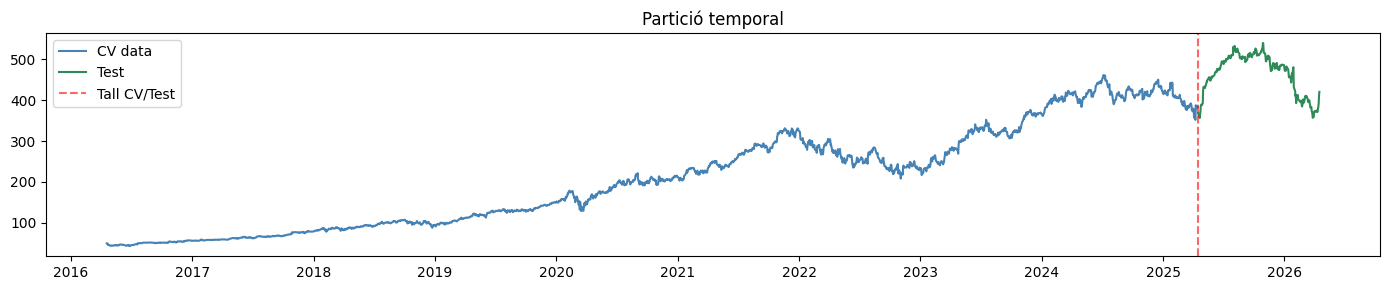

In [6]:
n      = len(y)
n_test = int(n * TEST_RATIO)
n_cv   = n - n_test

y_cv   = y.iloc[:n_cv]
y_test = y.iloc[n_cv:]

print(f"CV data : {len(y_cv):4d} pts  ({y_cv.index[0].date()} → {y_cv.index[-1].date()})")
print(f"Test    : {len(y_test):4d} pts  ({y_test.index[0].date()} → {y_test.index[-1].date()})")

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(y_cv.index,   y_cv.values,   label="CV data", color="steelblue")
ax.plot(y_test.index, y_test.values, label="Test",    color="seagreen")
ax.axvline(y_test.index[0], color="red", linestyle="--", alpha=0.6, label="Tall CV/Test")
ax.set_title("Partició temporal")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Walk-forward Cross-Validation (expanding window)

### Per què aquest esquema en lloc d'un sol tall train/val?

Amb un únic tall `train | val | test`, l'estimació del rendiment depèn d'un sol fragment de la sèrie, que pot tenir comportaments atípics (volatilitat puntual, tendència inusual...). El MAE d'aquell únic tall pot ser enganyós: el model pot semblar molt bo o molt dolent per atzar.

El **walk-forward CV amb expanding window** soluciona això:

```
Fold 1:  [■·········] [□]  ···········  (test, mai es toca)
Fold 2:  [■■········] [□]  ···········  (test, mai es toca)
Fold 3:  [■■■·······] [□]  ···········  (test, mai es toca)
  ...          ...
Fold k:  [■■■■■■■■■■] [□]  ···········  (test, mai es toca)
```

- Obenim **`N_FOLDS` estimacions independents** del MAE: la mitjana és molt més estable i robusta.
- La desviació estàndard entre folds indica la **consistència** del model.
- Respecta estrictament l'**ordre temporal**: mai es veu el futur.
- El MAE de CV és la mètrica per **comparar models** o triar hiperparàmetres sense contaminar el test.

> **Nota:** per a models computacionalment costosos (LSTM, etc.), redueix `N_FOLDS`.

Mida de cada tros: ~205 punts
 Fold  Train (pts)  Val (pts)  Val rang                             MAE
--------------------------------------------------------------------
    1          205        205  2017-02-08 → 2017-11-29             0.77
    2          410        205  2017-11-30 → 2018-09-24             1.13
    3          615        205  2018-09-25 → 2019-07-19             4.63
    4          820        205  2019-07-22 → 2020-05-12             2.21
    5         1025        205  2020-05-13 → 2021-03-05             2.20
    6         1230        205  2021-03-08 → 2021-12-27             4.38
    7         1435        205  2021-12-28 → 2022-10-19            29.44
    8         1640        205  2022-10-20 → 2023-08-15             8.06
    9         1845        205  2023-08-16 → 2024-06-07             5.95
   10         2050        205  2024-06-10 → 2025-04-03            24.52

MAE mitjà CV (H=22): 8.3290  ±9.6257
Llindar conformal IC 80%:  13.5851  (cobertura CV: 80.00%)
Llindar conf

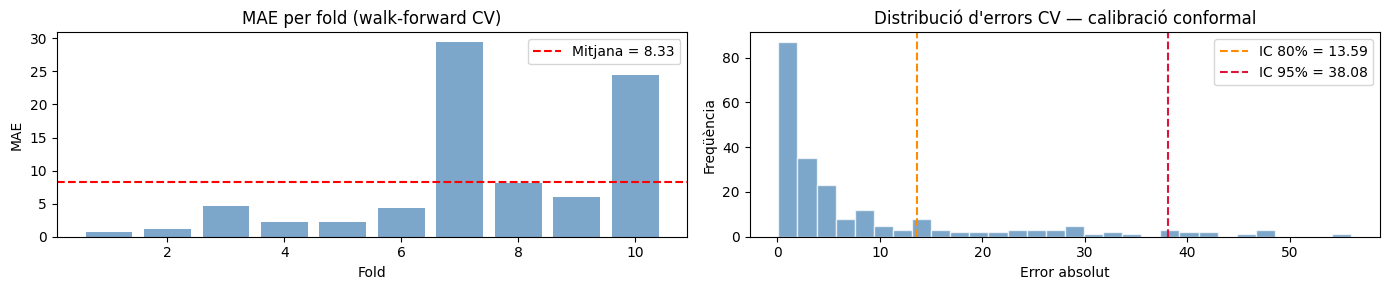

In [7]:
chunk_size = len(y_cv) // (N_FOLDS + 1)
chunks     = [y_cv.iloc[i * chunk_size:(i + 1) * chunk_size] for i in range(N_FOLDS + 1)]

print(f"Mida de cada tros: ~{chunk_size} punts")
print(f"{'Fold':>5}  {'Train (pts)':>11}  {'Val (pts)':>9}  {'Val rang':<30}  {'MAE':>8}")
print("-" * 68)

fold_maes   = []
fold_errors = []   # errors absoluts out-of-sample de tots els folds — base de calibració conformal

for fold in range(N_FOLDS):
    y_fold_train = pd.concat(chunks[:fold + 1])
    y_fold_val   = chunks[fold + 1]

    h_fold = min(HORIZON, len(y_fold_val))
    m_fold = train_fn(y_fold_train)
    p_fold = m_fold.predict(h_fold)
    y_true = y_fold_val.values[:h_fold]

    errors_fold = np.abs(y_true - p_fold["mean"][:h_fold])
    mae_fold    = float(np.mean(errors_fold))

    fold_maes.append(mae_fold)
    fold_errors.extend(errors_fold.tolist())

    val_start = y_fold_val.index[0].date()
    val_end   = y_fold_val.index[-1].date()
    print(f"{fold + 1:>5}  {len(y_fold_train):>11}  {len(y_fold_val):>9}  {str(val_start) + ' → ' + str(val_end):<30}  {mae_fold:>8.2f}")

cv_mae = float(np.mean(fold_maes))

# ── Calibració conformal ───────────────────────────────────────────────────
# Llindars empírics a partir dels errors out-of-sample del CV (CV+ conformal prediction).
# Per construcció, la cobertura sobre els mateixos errors serà exactament ~80% i ~95%.
threshold_80 = float(np.quantile(fold_errors, 0.80))
threshold_95 = float(np.quantile(fold_errors, 0.95))

cv_cov_80 = float(np.mean(np.array(fold_errors) <= threshold_80))
cv_cov_95 = float(np.mean(np.array(fold_errors) <= threshold_95))

print(f"\nMAE mitjà CV (H={HORIZON}): {cv_mae:.4f}  ±{np.std(fold_maes):.4f}")
print(f"Llindar conformal IC 80%:  {threshold_80:.4f}  (cobertura CV: {cv_cov_80:.2%})")
print(f"Llindar conformal IC 95%:  {threshold_95:.4f}  (cobertura CV: {cv_cov_95:.2%})")

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
axes[0].bar(range(1, N_FOLDS + 1), fold_maes, color="steelblue", alpha=0.7)
axes[0].axhline(cv_mae, color="red", linestyle="--", label=f"Mitjana = {cv_mae:.2f}")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("MAE")
axes[0].set_title("MAE per fold (walk-forward CV)")
axes[0].legend()
axes[1].hist(fold_errors, bins=30, color="steelblue", alpha=0.7, edgecolor="white")
axes[1].axvline(threshold_80, color="darkorange", linestyle="--", linewidth=1.5, label=f"IC 80% = {threshold_80:.2f}")
axes[1].axvline(threshold_95, color="crimson",    linestyle="--", linewidth=1.5, label=f"IC 95% = {threshold_95:.2f}")
axes[1].set_xlabel("Error absolut")
axes[1].set_ylabel("Freqüència")
axes[1].set_title("Distribució d'errors CV — calibració conformal")
axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Entrenament final

Un cop els hiperparàmetres s'han decidit a partir del CV, entrenem el model definitiu sobre **totes les dades de CV**.

In [8]:
model = train_fn(y_cv)
print(f"Model '{MODEL_NAME}' entrenat sobre {len(y_cv)} punts.")

Model 'Drift' entrenat sobre 2263 punts.


## 6. Predicció probabilística sobre el test

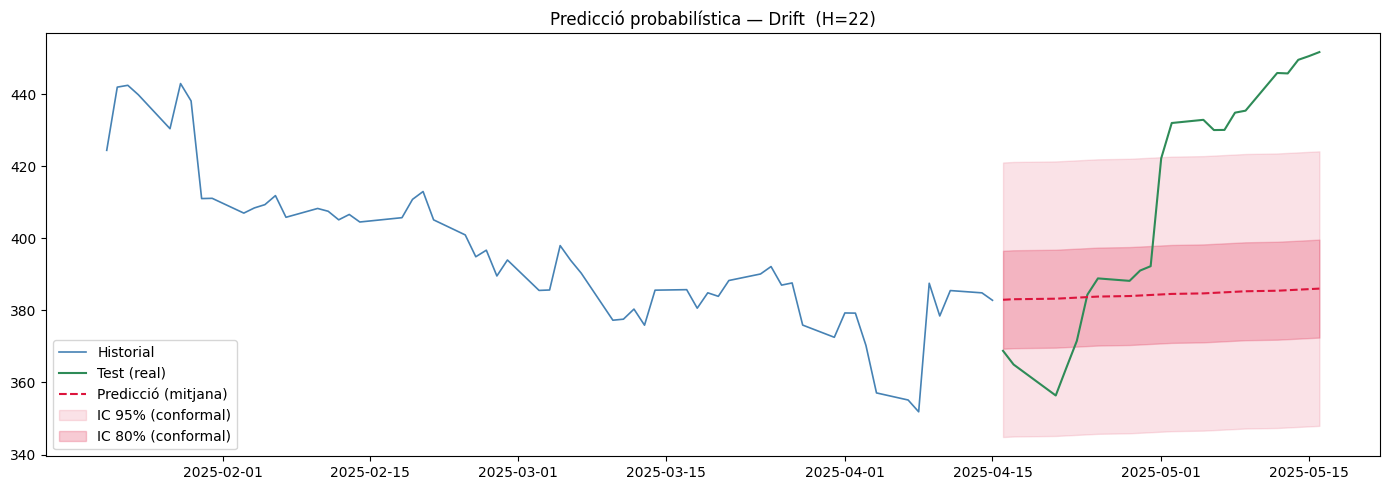

In [9]:
h_pred   = min(HORIZON, len(y_test))
preds    = model.predict(h_pred)
pred_idx = y_test.index[:h_pred]
y_actual = y_test.values[:h_pred]

# Substituïm els intervals interns del model pels llindars conformals calibrats al CV
preds["lower_80"] = preds["mean"] - threshold_80
preds["upper_80"] = preds["mean"] + threshold_80
preds["lower_95"] = preds["mean"] - threshold_95
preds["upper_95"] = preds["mean"] + threshold_95

context_n = min(60, len(y_cv))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_cv.index[-context_n:], y_cv.values[-context_n:],
        color="steelblue", label="Historial", linewidth=1.2)
ax.plot(pred_idx, y_actual,
        color="seagreen", label="Test (real)", linewidth=1.5)
ax.plot(pred_idx, preds["mean"],
        color="crimson", linestyle="--", label="Predicció (mitjana)", linewidth=1.5)
ax.fill_between(pred_idx, preds["lower_95"], preds["upper_95"],
                alpha=0.12, color="crimson", label="IC 95% (conformal)")
ax.fill_between(pred_idx, preds["lower_80"], preds["upper_80"],
                alpha=0.22, color="crimson", label="IC 80% (conformal)")
ax.set_title(f"Predicció probabilística — {MODEL_NAME}  (H={h_pred})")
ax.legend()
plt.tight_layout()
plt.show()

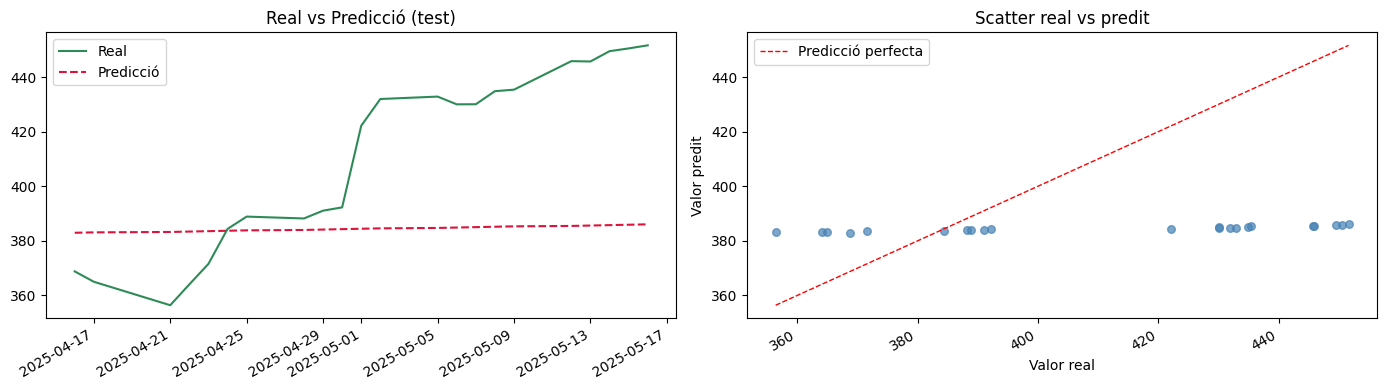

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Esquerra: sèrie temporal real vs predicha
axes[0].plot(pred_idx, y_actual,      label="Real",      color="seagreen", linewidth=1.5)
axes[0].plot(pred_idx, preds["mean"], label="Predicció", color="crimson",  linewidth=1.5, linestyle="--")
axes[0].set_title("Real vs Predicció (test)")
axes[0].legend()

# Dreta: scatter real vs predicció (diagonal perfecta = model perfecte)
axes[1].scatter(y_actual, preds["mean"], alpha=0.7, color="steelblue", s=30)
lims = [min(y_actual.min(), preds["mean"].min()), max(y_actual.max(), preds["mean"].max())]
axes[1].plot(lims, lims, color="red", linestyle="--", linewidth=1, label="Predicció perfecta")
axes[1].set_xlabel("Valor real")
axes[1].set_ylabel("Valor predit")
axes[1].set_title("Scatter real vs predit")
axes[1].legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 7. Avaluació de mètriques

In [11]:
def _mae(yt, yp):       return float(np.mean(np.abs(yt - yp)))
def _rmse(yt, yp):      return float(np.sqrt(np.mean((yt - yp) ** 2)))
def _mase(yt, yp, ref): return _mae(yt, yp) / float(np.mean(np.abs(np.diff(ref.values))))
def _cov(yt, lo, hi):   return float(np.mean((yt >= lo) & (yt <= hi)))

metrics = {
    "model":            MODEL_NAME,
    "horizon":          h_pred,
    "cv_mae_mean":      round(cv_mae, 6),
    "cv_mae_std":       round(float(np.std(fold_maes)), 6),
    "cv_coverage_80":   round(cv_cov_80, 4),
    "cv_coverage_95":   round(cv_cov_95, 4),
    "test_mae":         round(_mae(y_actual,  preds["mean"]), 6),
    "test_rmse":        round(_rmse(y_actual, preds["mean"]), 6),
    "test_mase":        round(_mase(y_actual, preds["mean"], y_cv), 6),
    "test_coverage_80": round(_cov(y_actual, preds["lower_80"], preds["upper_80"]), 4),
    "test_coverage_95": round(_cov(y_actual, preds["lower_95"], preds["upper_95"]), 4),
}

print(json.dumps(metrics, indent=2))

{
  "model": "Drift",
  "horizon": 22,
  "cv_mae_mean": 8.329016,
  "cv_mae_std": 9.625683,
  "cv_coverage_80": 0.8,
  "cv_coverage_95": 0.95,
  "test_mae": 34.23128,
  "test_rmse": 40.881003,
  "test_mase": 13.731403,
  "test_coverage_80": 0.2727,
  "test_coverage_95": 0.5
}


## 8. Guardar resultats

Es crea `../results/<MODEL_NAME>/` amb:
- `metrics.json` — totes les mètriques d'avaluació
- `model.pkl` — objecte model serialitzat

In [12]:
results_dir = Path("../results") / RESULTS_VERSION / MODEL_NAME
results_dir.mkdir(parents=True, exist_ok=True)

with open(results_dir / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

with open(results_dir / "model.pkl", "wb") as f:
    pickle.dump(model, f)

print(f"Resultats guardats a: {results_dir.resolve()}")
print(f"  metrics.json  <- mètriques d'avaluació")
print(f"  model.pkl     <- objecte model serialitzat")

Resultats guardats a: /home/joanguest/Documents/GitHub Repositories/TimeSeriesExercice/results/v2/Drift
  metrics.json  <- mètriques d'avaluació
  model.pkl     <- objecte model serialitzat
